## In Class Activity April 21st

In [24]:
# pip install category_encoders

### Libraries, data import & EDA

In [25]:
# importing libraries
import numpy as np
import pandas as pd
from scipy.stats import boxcox
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
import sweetviz as sv
from sklearn.cluster import KMeans
import category_encoders as ce
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

In [26]:
# importing the data
adult = pd.read_csv("adult.csv")
adult.head()
 

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [27]:
# quick eda with sweetviz
report = sv.analyze(adult)
report.show_html("sweetviz_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


### Model agnostic data preprocessing & train/test split for reuse in all cells

In [28]:
# replace ? with np.nan
adult = adult.replace("?", np.nan)
adult.head()

# convert target variable to binary
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)

# convert gender to 0/1 (doesn't need categorical encoding since it's binary)
if "gender" in adult.columns:
    adult["gender"] = adult["gender"].apply(lambda x: 1 if x == "Male" else 0)  
    
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,0,0,0,30,United-States,0


In [29]:
# fixed train/test split for the entire notebook

train_idx, test_idx = train_test_split(
    adult.index,
    test_size=0.2,
    stratify=adult["income"],
    random_state=42
)

print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))

Train rows: 39073
Test rows: 9769


### Preprocessing for models without native category handling

In [30]:
# one hot encoding low cardinality features for models that don't handle categorical variables natively

adult_ohe = adult.copy()

adult_ohe = pd.get_dummies(
    adult_ohe,
    columns=["marital-status", "relationship", "race", "workclass"],
    drop_first=True
)

# quick target encoding for screening only (this has data leakage--screening only, not for final model)
occupation_encoder = ce.TargetEncoder(cols=["occupation"])
adult_ohe["occupation_encoded"] = occupation_encoder.fit_transform(
    adult_ohe[["occupation"]], adult_ohe["income"]
)["occupation"]

native_country_encoder = ce.TargetEncoder(cols=["native-country"])
adult_ohe["native_country_encoded"] = native_country_encoder.fit_transform(
    adult_ohe[["native-country"]], adult_ohe["income"]
)["native-country"]

adult_ohe.head()

,age,fnlwgt,education,educational-num,occupation,gender,capital-gain,capital-loss,hours-per-week,native-country,...,race_White,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,occupation_encoded,native_country_encoded
0,25,226802,11th,7,Machine-op-inspct,1,0,0,40,United-States,...,False,False,False,True,False,False,False,False,0.123097,0.243977
1,38,89814,HS-grad,9,Farming-fishing,1,0,0,50,United-States,...,True,False,False,True,False,False,False,False,0.116107,0.243977
2,28,336951,Assoc-acdm,12,Protective-serv,1,0,0,40,United-States,...,True,True,False,False,False,False,False,False,0.313327,0.243977
3,44,160323,Some-college,10,Machine-op-inspct,1,7688,0,40,United-States,...,False,False,False,True,False,False,False,False,0.123097,0.243977
4,18,103497,Some-college,10,NaN,0,0,0,30,United-States,...,True,False,False,False,False,False,False,False,0.094340,0.243977


### Feature-engine library 

In [31]:
# OPTIONAL standalone example using feature-engine

# if needed:
# !pip install feature-engine

from feature_engine.transformation import YeoJohnsonTransformer
from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder

df_fe = adult.copy()

cat_cols = df_fe.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = ["capital-gain", "capital-loss"]

# make missing categorical values explicit
df_fe[cat_cols] = df_fe[cat_cols].fillna("Unknown")

# transform skewed numeric features
yj = YeoJohnsonTransformer(variables=num_cols)
df_fe = yj.fit_transform(df_fe)

# group rare categories
rare = RareLabelEncoder(tol=0.01, variables=cat_cols)
df_fe = rare.fit_transform(df_fe)

# frequency encode categorical variables
freq = CountFrequencyEncoder(variables=cat_cols, encoding_method="frequency")
df_fe = freq.fit_transform(df_fe)

print("Example after feature-engine transformations + encoding:")
print(df_fe[num_cols + cat_cols[:3]].head())

Example after feature-engine transformations + encoding:
   capital-gain  capital-loss  workclass  education  marital-status
0      0.000000           0.0   0.694198   0.037099        0.329982
1      0.000000           0.0   0.694198   0.323164        0.458192
2      0.000000           0.0   0.064207   0.032779        0.458192
3      0.728649           0.0   0.694198   0.222718        0.458192
4      0.000000           0.0   0.057307   0.222718        0.329982


/opt/anaconda3/lib/python3.13/site-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable workclass is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable marital-status is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable relationship is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable race is less than that indicated in n_categories.

#### Baseline modeling with CV

In [32]:
# baseline models with CV
X = adult_ohe.drop(columns=["income", "occupation", "fnlwgt", "education", "native-country"])
y = adult_ohe["income"]

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, class_weight="balanced")
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=kf, scoring="accuracy")
print(f"RF CV Accuracy: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("RF Test Accuracy:", accuracy_score(y_test, rf_pred))
print("RF Classification Report:\n", classification_report(y_test, rf_pred))

xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, subsample=0.8, random_state=42, eval_metric="logloss")
xgb_cv_scores = cross_val_score(xgb, X_train, y_train, cv=kf, scoring="accuracy")
print(f"XGB CV Accuracy: {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("XGB Test Accuracy:", accuracy_score(y_test, xgb_pred))
print("XGB Classification Report:\n", classification_report(y_test, xgb_pred))

RF CV Accuracy: 0.8023 ± 0.0031
RF Test Accuracy: 0.8022315487767427
RF Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.78      0.86      7431
           1       0.56      0.87      0.68      2338

    accuracy                           0.80      9769
   macro avg       0.75      0.83      0.77      9769
weighted avg       0.86      0.80      0.81      9769

XGB CV Accuracy: 0.8712 ± 0.0050
XGB Test Accuracy: 0.8760364418057119
XGB Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92      7431
           1       0.80      0.65      0.71      2338

    accuracy                           0.88      9769
   macro avg       0.85      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



### Which features are important?

In [33]:
# feature importance from baseline models using one hot encoded features
rf_importance = rf.feature_importances_
xgb_importance = xgb.feature_importances_
feature_names = X_train.columns
rf_importance_df = pd.DataFrame({"feature": feature_names, "importance": rf_importance})
xgb_importance_df = pd.DataFrame({"feature": feature_names, "importance": xgb_importance})
rf_importance_df = rf_importance_df.sort_values(by="importance", ascending=False)
xgb_importance_df = xgb_importance_df.sort_values(by="importance", ascending=False)
print("Top 10 RF Features:\n", rf_importance_df.head(10))
print("Top 10 XGB Features:\n", xgb_importance_df.head(10))

Top 10 RF Features:
                               feature  importance
7   marital-status_Married-civ-spouse    0.256652
0                                 age    0.115236
28                 occupation_encoded    0.112052
1                     educational-num    0.109843
3                        capital-gain    0.104411
9        marital-status_Never-married    0.085959
12         relationship_Not-in-family    0.038885
5                      hours-per-week    0.036482
14             relationship_Own-child    0.030835
2                              gender    0.029383
Top 10 XGB Features:
                               feature  importance
7   marital-status_Married-civ-spouse    0.631602
3                        capital-gain    0.061792
1                     educational-num    0.058238
28                 occupation_encoded    0.031861
14             relationship_Own-child    0.029987
4                        capital-loss    0.024288
0                                 age    0.015014
9      

### Where are the errors happening?

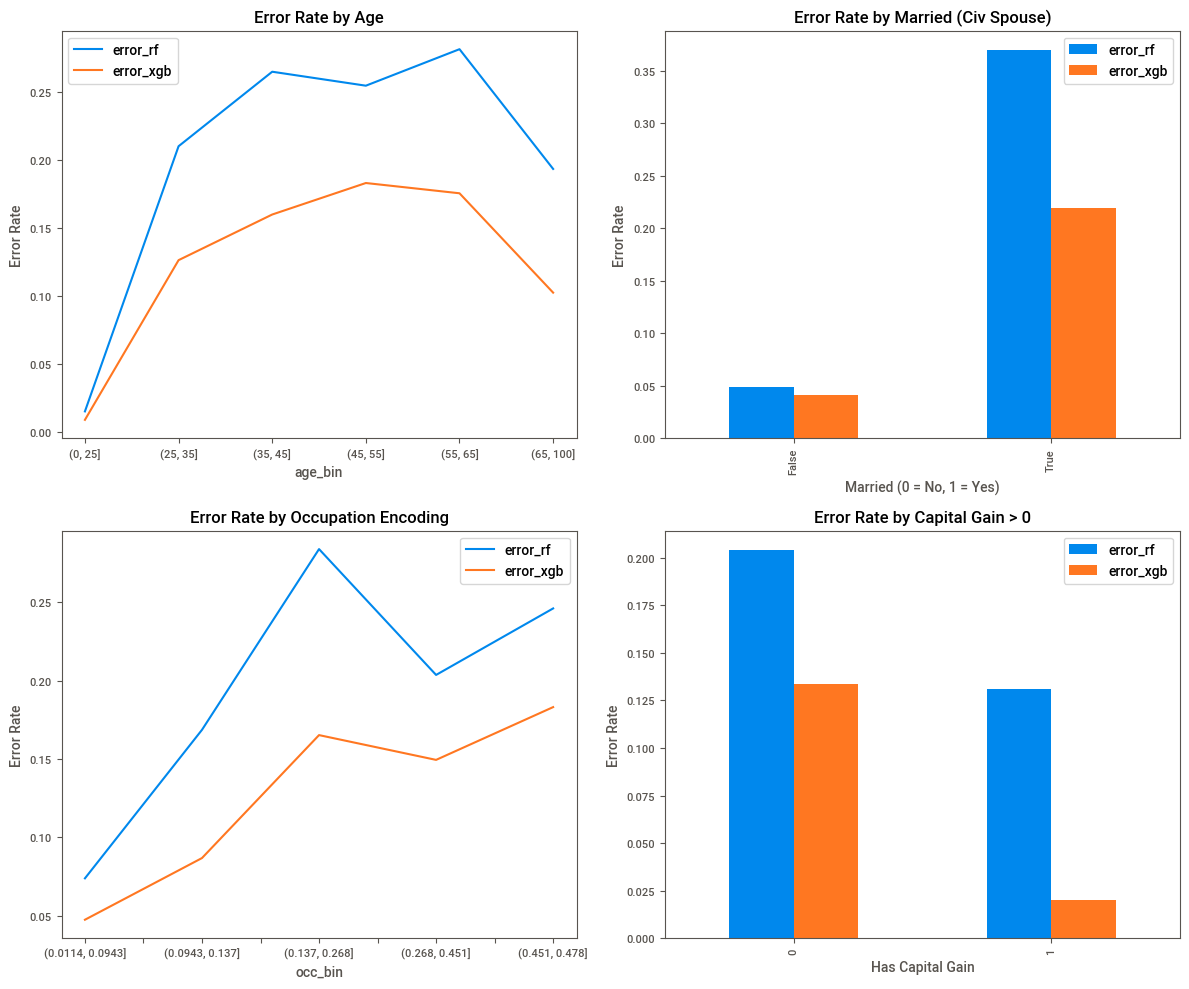

In [34]:
# build error dataframe
df_err = X_test.copy()
df_err["y_true"] = y_test
df_err["error_rf"] = (rf_pred != y_test).astype(int)
df_err["error_xgb"] = (xgb_pred != y_test).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- 1. Error vs Age (binned) ---
df_err["age_bin"] = pd.cut(df_err["age"], bins=[0, 25, 35, 45, 55, 65, 100])
df_err.groupby("age_bin", observed=False)[["error_rf", "error_xgb"]].mean().plot(ax=axes[0,0])
axes[0,0].set_title("Error Rate by Age")
axes[0,0].set_ylabel("Error Rate")

# --- 2. Error vs Married ---
df_err.groupby("marital-status_Married-civ-spouse")[["error_rf", "error_xgb"]].mean().plot(kind="bar", ax=axes[0,1])
axes[0,1].set_title("Error Rate by Married (Civ Spouse)")
axes[0,1].set_xlabel("Married (0 = No, 1 = Yes)")
axes[0,1].set_ylabel("Error Rate")

# --- 3. Error vs Occupation Encoded (binned) ---
df_err["occ_bin"] = pd.qcut(df_err["occupation_encoded"], q=5, duplicates="drop")
df_err.groupby("occ_bin", observed=False)[["error_rf", "error_xgb"]].mean().plot(ax=axes[1,0])
axes[1,0].set_title("Error Rate by Occupation Encoding")
axes[1,0].set_ylabel("Error Rate")

# --- 4. Error vs Capital Gain (binary) ---
df_err["has_gain"] = (df_err["capital-gain"] > 0).astype(int)
df_err.groupby("has_gain")[["error_rf", "error_xgb"]].mean().plot(kind="bar", ax=axes[1,1])
axes[1,1].set_title("Error Rate by Capital Gain > 0")
axes[1,1].set_xlabel("Has Capital Gain")
axes[1,1].set_ylabel("Error Rate")

plt.tight_layout()
plt.show()

### OOF Target Encoding & New Interaction Features

In [35]:
# proper OOF target encoding: split first, OOF encode train, encode test from full train
from sklearn.model_selection import KFold

X_base = adult_ohe.drop(columns=["income"]).copy()
y_base = adult_ohe["income"].copy()

X_train_base = X_base.loc[train_idx].copy()
X_test_base = X_base.loc[test_idx].copy()
y_train_base = y_base.loc[train_idx].copy()
y_test_base = y_base.loc[test_idx].copy()

def add_oof_target_encoding(X_train, X_test, y_train, col, new_col, n_splits=5):
    X_train = X_train.copy()
    X_test = X_test.copy()

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    X_train[new_col] = np.nan

    for tr_idx, val_idx in kf.split(X_train):
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]

        encoder = ce.TargetEncoder(cols=[col])
        encoder.fit(X_tr[[col]], y_tr)

        X_train.iloc[val_idx, X_train.columns.get_loc(new_col)] = (
            encoder.transform(X_val[[col]])[col].values
        )

    final_encoder = ce.TargetEncoder(cols=[col])
    final_encoder.fit(X_train[[col]], y_train)
    X_test[new_col] = final_encoder.transform(X_test[[col]])[col].values

    return X_train, X_test

X_train_oof, X_test_oof = add_oof_target_encoding(
    X_train_base, X_test_base, y_train_base,
    col="occupation", new_col="occupation_oof"
)

X_train_oof, X_test_oof = add_oof_target_encoding(
    X_train_oof, X_test_oof, y_train_base,
    col="native-country", new_col="native_country_oof"
)

X_train_oof.head()

,age,fnlwgt,education,educational-num,occupation,gender,capital-gain,capital-loss,hours-per-week,native-country,...,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,occupation_encoded,native_country_encoded,occupation_oof,native_country_oof
34342,71,77253,HS-grad,9,Handlers-cleaners,1,0,0,17,United-States,...,False,True,False,False,False,False,0.066602,0.243977,0.066375,0.243592
18559,17,329783,10th,6,Sales,0,0,0,10,United-States,...,False,True,False,False,False,False,0.267987,0.243977,0.265369,0.243269
12477,27,91257,HS-grad,9,Other-service,1,0,0,40,El-Salvador,...,False,True,False,False,False,False,0.041438,0.070968,0.039834,0.075380
560,43,125577,HS-grad,9,Adm-clerical,0,0,0,40,United-States,...,False,True,False,False,False,False,0.136874,0.243977,0.144047,0.243269
3427,31,137978,Bachelors,13,Exec-managerial,1,0,0,40,United-States,...,False,True,False,False,False,False,0.477818,0.243977,0.488712,0.244195


In [36]:
# engineering new feature based on error analysis insights
X_train_oof["married_occ_interaction"] = (
    X_train_oof["marital-status_Married-civ-spouse"] * X_train_oof["occupation_oof"]
)

X_test_oof["married_occ_interaction"] = (
    X_test_oof["marital-status_Married-civ-spouse"] * X_test_oof["occupation_oof"]
)

X_train_oof[["marital-status_Married-civ-spouse", "occupation_oof", "married_occ_interaction"]].head()

,marital-status_Married-civ-spouse,occupation_oof,married_occ_interaction
34342,False,0.066375,0.000000
18559,False,0.265369,0.000000
12477,True,0.039834,0.039834
560,False,0.144047,0.000000
3427,True,0.488712,0.488712


In [37]:
# Creating even more engineered features
# age and education interaction (hypothesis: the effect of education on income might differ by age)
X_train_oof["age_education_interaction"] = X_train_oof["age"] * X_train_oof["educational-num"]
X_test_oof["age_education_interaction"] = X_test_oof["age"] * X_test_oof["educational-num"]
# capital gain/loss indicator (hypothesis: having any capital gain or loss might be more informative than the amount)
X_train_oof["has_capital_gain"] = (X_train_oof["capital-gain"] > 0).astype(int)
X_train_oof["has_capital_loss"] = (X_train_oof["capital-loss"] > 0).astype(int)
X_test_oof["has_capital_gain"] = (X_test_oof["capital-gain"] > 0).astype(int)
X_test_oof["has_capital_loss"] = (X_test_oof["capital-loss"] > 0).astype(int)
# work intensity feature (hypothesis: the combination of hours worked per week and occupation might capture work intensity)
X_train_oof["work_intensity"] = (X_train_oof["hours-per-week"] >= 40).astype(int)
X_test_oof["work_intensity"] = (X_test_oof["hours-per-week"] >= 40).astype(int)





In [38]:
# modeling with new OOF and interaction features
drop_cols = ["occupation", "fnlwgt", "education", "native-country", 
             "occupation_encoded", "native_country_encoded"]

X_train = X_train_oof.drop(columns=drop_cols)
X_test = X_test_oof.drop(columns=drop_cols)
y_train = y_train_base
y_test = y_test_base

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, class_weight="balanced")
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=kf, scoring="accuracy")
print(f"RF CV Accuracy: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("RF Test Accuracy:", accuracy_score(y_test, rf_pred))
print("RF Classification Report:\n", classification_report(y_test, rf_pred))

xgb = XGBClassifier(n_estimators=100, max_depth=10, learning_rate=0.1, subsample=0.8, min_samples_leaf=5, random_state=42, eval_metric="logloss")
xgb_cv_scores = cross_val_score(xgb, X_train, y_train, cv=kf, scoring="accuracy")
print(f"XGB CV Accuracy: {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("XGB Test Accuracy:", accuracy_score(y_test, xgb_pred))
print("XGB Classification Report:\n", classification_report(y_test, xgb_pred))

RF CV Accuracy: 0.8147 ± 0.0044
RF Test Accuracy: 0.8125703756781656
RF Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.80      0.87      7431
           1       0.57      0.86      0.69      2338

    accuracy                           0.81      9769
   macro avg       0.76      0.83      0.78      9769
weighted avg       0.86      0.81      0.82      9769



/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [16:32:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [16:32:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [16:32:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [16:32:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fo

XGB CV Accuracy: 0.8684 ± 0.0032


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [16:32:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB Test Accuracy: 0.8737844201044119
XGB Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92      7431
           1       0.79      0.65      0.71      2338

    accuracy                           0.87      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.87      0.87      9769



In [39]:
# feature importance from random forest
rf_importance = rf.feature_importances_
feature_names = X_train.columns
rf_importance_df = pd.DataFrame({"feature": feature_names, "importance": rf_importance})
rf_importance_df = rf_importance_df.sort_values(by="importance", ascending=False)       
print("Top 10 RF Features:\n", rf_importance_df.head(10))   

# feature importance from xgboost
xgb_importance = xgb.feature_importances_
xgb_importance_df = pd.DataFrame({"feature": feature_names, "importance": xgb_importance})
xgb_importance_df = xgb_importance_df.sort_values(by="importance", ascending=False)
print("Top 10 XGB Features:\n", xgb_importance_df.head(10))

Top 10 RF Features:
                               feature  importance
30            married_occ_interaction    0.206167
7   marital-status_Married-civ-spouse    0.157169
31          age_education_interaction    0.127380
28                     occupation_oof    0.079931
3                        capital-gain    0.077846
1                     educational-num    0.067367
0                                 age    0.058167
9        marital-status_Never-married    0.041529
5                      hours-per-week    0.031160
32                   has_capital_gain    0.027955
Top 10 XGB Features:
                              feature  importance
30           married_occ_interaction    0.342926
3                       capital-gain    0.141697
1                    educational-num    0.055270
4                       capital-loss    0.049706
31         age_education_interaction    0.030812
13       relationship_Other-relative    0.020566
25        workclass_Self-emp-not-inc    0.020432
2              

In [40]:
# building xgboost using native categorical feature handling

adult_cat = adult.copy()

for col in ["workclass", "education", "marital-status", "occupation", "relationship", "race", "native-country"]:
    adult_cat[col] = adult_cat[col].fillna("Unknown").astype("category")

X_cat = adult_cat.drop(columns=["income", "fnlwgt"])
y_cat = adult_cat["income"]

X_train_cat = X_cat.loc[train_idx]
X_test_cat = X_cat.loc[test_idx]
y_train_cat = y_cat.loc[train_idx]
y_test_cat = y_cat.loc[test_idx]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_cat = XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42,
    eval_metric="logloss",
    enable_categorical=True,
    tree_method="hist"
)

xgb_cat_cv_scores = cross_val_score(xgb_cat, X_train_cat, y_train_cat, cv=kf, scoring="accuracy")
print(f"XGB with Native Cat CV Accuracy: {xgb_cat_cv_scores.mean():.4f} ± {xgb_cat_cv_scores.std():.4f}")

xgb_cat.fit(X_train_cat, y_train_cat)
xgb_cat_pred = xgb_cat.predict(X_test_cat)

print("XGB with Native Cat Test Accuracy:", accuracy_score(y_test_cat, xgb_cat_pred))
print("XGB with Native Cat Classification Report:\n", classification_report(y_test_cat, xgb_cat_pred))

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [16:32:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [16:32:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [16:32:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [16:32:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fo

XGB with Native Cat CV Accuracy: 0.8699 ± 0.0032


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [16:32:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB with Native Cat Test Accuracy: 0.8752175248234211
XGB with Native Cat Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92      7431
           1       0.79      0.66      0.72      2338

    accuracy                           0.88      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



In [41]:
# feature importance from xgboost with native categorical handling
xgb_cat_importance = xgb_cat.feature_importances_
feature_names = X_train.columns
feature_names = X_train_cat.columns
xgb_cat_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_cat_importance
})
xgb_cat_importance_df = xgb_cat_importance_df.sort_values(by="importance", ascending=False)
print("Top 10 XGB with Native Cat Features:\n", xgb_cat_importance_df.head(10)) 

Top 10 XGB with Native Cat Features:
            feature  importance
6     relationship    0.341682
9     capital-gain    0.219183
4   marital-status    0.119062
2        education    0.070026
10    capital-loss    0.068220
5       occupation    0.045875
0              age    0.024071
11  hours-per-week    0.022342
12  native-country    0.021460
1        workclass    0.020893


### Stacking predictions-average

In [42]:
# building ensemble of RF and XGB with native categorical handling

# RF data from OOF / one-hot path
drop_cols = ["occupation", "fnlwgt", "education", "native-country", "occupation_encoded", "native_country_encoded"]

X_train_ohe = X_train_oof.drop(columns=drop_cols)
X_test_ohe = X_test_oof.drop(columns=drop_cols)

y_train = y_train_base
y_test = y_test_base

# native categorical data from cat path
X_train_cat = adult_cat.drop(columns=["income", "fnlwgt"]).loc[train_idx]
X_test_cat = adult_cat.drop(columns=["income", "fnlwgt"]).loc[test_idx]

rf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, class_weight="balanced")
rf.fit(X_train_ohe, y_train)
y_pred_rf = rf.predict(X_test_ohe)
rf_probs = rf.predict_proba(X_test_ohe)[:, 1]

xgb_cat = XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42,
    eval_metric="logloss",
    enable_categorical=True,
    tree_method="hist"
)
xgb_cat.fit(X_train_cat, y_train)
y_pred_xgb_cat = xgb_cat.predict(X_test_cat)
xgb_cat_probs = xgb_cat.predict_proba(X_test_cat)[:, 1]

avg_probs = (rf_probs + xgb_cat_probs) / 2
y_pred_avg = (avg_probs >= 0.5).astype(int)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("XGB (cat) Accuracy:", accuracy_score(y_test, y_pred_xgb_cat))
print("Ensemble Accuracy:", accuracy_score(y_test, y_pred_avg))

print("\nEnsemble Classification Report:")
print(classification_report(y_test, y_pred_avg))

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [16:32:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RF Accuracy: 0.8125703756781656
XGB (cat) Accuracy: 0.8752175248234211
Ensemble Accuracy: 0.8623195823523391

Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      7431
           1       0.69      0.76      0.73      2338

    accuracy                           0.86      9769
   macro avg       0.81      0.83      0.82      9769
weighted avg       0.87      0.86      0.86      9769



### Stacking predictions-weighted

In [43]:
# adjusting weights for averaging predictions from RF and XGB using Optuna
import optuna
def objective(trial):
    rf_weight = trial.suggest_float("rf_weight", 0.0, 1.0)
    xgb_weight = 1.0 - rf_weight
    
    combined_probs = rf_weight * rf_probs + xgb_weight * xgb_cat_probs
    y_pred_combined = (combined_probs >= 0.5).astype(int)
    
    return accuracy_score(y_test, y_pred_combined)  
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)  

# best weights
best_rf_weight = study.best_params["rf_weight"]
best_xgb_weight = 1.0 - best_rf_weight
print(f"Best RF Weight: {best_rf_weight:.4f}, Best XGB Weight: {best_xgb_weight:.4f}")  


[I 2026-04-22 16:32:43,093] A new study created in memory with name: no-name-41ba5081-e712-4a57-af8d-3dfbcf3506c5
[I 2026-04-22 16:32:43,100] Trial 0 finished with value: 0.8381615313747569 and parameters: {'rf_weight': 0.7654366481996743}. Best is trial 0 with value: 0.8381615313747569.
[I 2026-04-22 16:32:43,101] Trial 1 finished with value: 0.8768553587880029 and parameters: {'rf_weight': 0.06867279360816447}. Best is trial 1 with value: 0.8768553587880029.
[I 2026-04-22 16:32:43,103] Trial 2 finished with value: 0.8761388064284983 and parameters: {'rf_weight': 0.19873091151175437}. Best is trial 1 with value: 0.8768553587880029.
[I 2026-04-22 16:32:43,106] Trial 3 finished with value: 0.86539052103593 and parameters: {'rf_weight': 0.47133011716641615}. Best is trial 1 with value: 0.8768553587880029.
[I 2026-04-22 16:32:43,108] Trial 4 finished with value: 0.870713481420821 and parameters: {'rf_weight': 0.37961287157479884}. Best is trial 1 with value: 0.8768553587880029.
[I 2026-04

Best RF Weight: 0.0687, Best XGB Weight: 0.9313


In [44]:
# building final ensemble with best weights
final_combined_probs = best_rf_weight * rf_probs + best_xgb_weight * xgb_cat_probs
y_pred_final = (final_combined_probs >= 0.5).astype(int)    
print("Final Ensemble Accuracy:", accuracy_score(y_test, y_pred_final))
print("\nFinal Ensemble Classification Report:")
print(classification_report(y_test, y_pred_final))


Final Ensemble Accuracy: 0.8768553587880029

Final Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      7431
           1       0.78      0.67      0.72      2338

    accuracy                           0.88      9769
   macro avg       0.84      0.81      0.82      9769
weighted avg       0.87      0.88      0.87      9769



### LASSO with one hot encoding for possible feature engineering ideas

In [45]:
# This is a standalone cell for you to copy and paste into a new notebook as desired
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression

df = adult.copy()

X = df.drop(columns=["income"])
y = df["income"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# handle missing values
X[categorical_features] = X[categorical_features].fillna("Unknown")
X[numeric_features] = X[numeric_features].fillna(X[numeric_features].median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
])

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    max_iter=2000
)

selector = SelectFromModel(lasso)
selector.fit(X_train_enc, y_train)

mask = selector.get_support()

selected_features = feature_names[mask]
dropped_features = feature_names[~mask]

print(f"Encoded features selected by Lasso: {mask.sum()} out of {len(mask)}")

coefs = pd.Series(selector.estimator_.coef_.ravel(), index=feature_names)
selected_coefs = coefs[coefs != 0].sort_values(key=np.abs, ascending=False)

print("\nTop selected encoded features by absolute Lasso coefficient:")
display(selected_coefs.head(20).to_frame("coefficient"))

print(f"\nDropped {len(dropped_features)} encoded features")
print("\nExample dropped encoded features:")
print(list(dropped_features[:20]))

rows = []

for col in numeric_features:
    fname = f"num__{col}"
    kept = int(fname in selected_features)
    rows.append({
        "original_feature": col,
        "type": "numeric",
        "total_encoded_cols": 1,
        "kept_cols": kept,
        "removed_cols": 1 - kept,
        "kept_pct": kept
    })

for col in categorical_features:
    prefix = f"cat__{col}_"
    total = sum(name.startswith(prefix) for name in feature_names)
    kept = sum(name.startswith(prefix) for name in selected_features)
    rows.append({
        "original_feature": col,
        "type": "categorical",
        "total_encoded_cols": total,
        "kept_cols": kept,
        "removed_cols": total - kept,
        "kept_pct": kept / total if total > 0 else np.nan
    })

summary = pd.DataFrame(rows).sort_values(
    by=["type", "kept_pct", "kept_cols"],
    ascending=[True, False, False]
)

print("\nSelection summary by original feature:")
display(summary)

dropped_rows = []

for col in categorical_features:
    prefix = f"cat__{col}_"
    kept = [name.replace(prefix, "") for name in selected_features if name.startswith(prefix)]
    dropped = [name.replace(prefix, "") for name in dropped_features if name.startswith(prefix)]
    dropped_rows.append({
        "feature": col,
        "kept_levels": kept,
        "dropped_levels": dropped
    })

dropped_df = pd.DataFrame(dropped_rows)

print("\nCategorical levels kept vs dropped:")
for _, row in dropped_df.iterrows():
    print("=" * 80)
    print(f"Feature: {row['feature']}")
    print(f"Kept levels ({len(row['kept_levels'])}): {row['kept_levels']}")
    print(f"Dropped levels ({len(row['dropped_levels'])}): {row['dropped_levels']}")

Encoded features selected by Lasso: 41 out of 100

Top selected encoded features by absolute Lasso coefficient:


,coefficient
num__capital-gain,2.216295
cat__marital-status_Married-civ-spouse,1.727293
cat__relationship_Wife,1.077830
cat__occupation_Farming-fishing,-0.923015
cat__occupation_Other-service,-0.891930
cat__occupation_Unknown,-0.862429
cat__relationship_Own-child,-0.805811
cat__workclass_Self-emp-not-inc,-0.729844
num__educational-num,0.727068
cat__occupation_Exec-managerial,0.713333



Dropped 59 encoded features

Example dropped encoded features:
['cat__workclass_Never-worked', 'cat__workclass_Without-pay', 'cat__education_12th', 'cat__education_1st-4th', 'cat__education_5th-6th', 'cat__education_7th-8th', 'cat__education_9th', 'cat__education_Bachelors', 'cat__education_Doctorate', 'cat__education_Masters', 'cat__education_Preschool', 'cat__marital-status_Married-AF-spouse', 'cat__marital-status_Married-spouse-absent', 'cat__marital-status_Separated', 'cat__marital-status_Widowed', 'cat__occupation_Armed-Forces', 'cat__occupation_Craft-repair', 'cat__occupation_Priv-house-serv', 'cat__relationship_Not-in-family', 'cat__race_Asian-Pac-Islander']

Selection summary by original feature:


,original_feature,type,total_encoded_cols,kept_cols,removed_cols,kept_pct
11,relationship,categorical,5,4,1,0.800000
10,occupation,categorical,14,11,3,0.785714
7,workclass,categorical,8,6,2,0.750000
12,race,categorical,4,2,2,0.500000
8,education,categorical,15,6,9,0.400000
9,marital-status,categorical,6,2,4,0.333333
13,native-country,categorical,41,3,38,0.073171
0,age,numeric,1,1,0,1.000000
1,fnlwgt,numeric,1,1,0,1.000000
2,educational-num,numeric,1,1,0,1.000000



Categorical levels kept vs dropped:
Feature: workclass
Kept levels (6): ['Local-gov', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Unknown']
Dropped levels (2): ['Never-worked', 'Without-pay']
Feature: education
Kept levels (6): ['11th', 'Assoc-acdm', 'Assoc-voc', 'HS-grad', 'Prof-school', 'Some-college']
Dropped levels (9): ['12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Bachelors', 'Doctorate', 'Masters', 'Preschool']
Feature: marital-status
Kept levels (2): ['Married-civ-spouse', 'Never-married']
Dropped levels (4): ['Married-AF-spouse', 'Married-spouse-absent', 'Separated', 'Widowed']
Feature: occupation
Kept levels (11): ['Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving', 'Unknown']
Dropped levels (3): ['Armed-Forces', 'Craft-repair', 'Priv-house-serv']
Feature: relationship
Kept levels (4): ['Other-relative', 'Own-child', 'Unmarried', 

### Evaluating my results:

I used random forest and xgboost classifiers as models for this assignment. I tuned hyperparameters and created new engineered features and evaluated the models to see the impact of these changes. For both models, I used interactions and indicator variables to add to the model. 

Briefly describe which features seemed most useful, which model performed best, and whether the ensemble improved performance.

The features that seemed the modst useful include marital status, occupation, education, and capital gain. Married_occ_interaction became the most important feature for both random forest and xgboost models, showing that combining marital status and occupation acts as a strong predictor. XGBoost performed the best with an accuracy of 0.875, while random forest dropped to about 0.81. The ensemble did improve performance to about 0.877, which outperformed all other models. This showed me that the ensemble can have a positive impact on model performance when the different models' contributions are effective.

Also comment on whether different models responded differently to your engineered features. 
 
The different models responded differently to the engineered features. The random forest model improved after adding the engineered features, and features like married_occ_interaction and age_education_interaction became very important. For XGBoost, the model performance slightly decreased even though the interaction features also showed as highly significant. 

Summarize how this will fit into your feature engineering and model building workflow.

In my workflow, I can now use error analysis and exploration to guide my feature engineering process. I can create a mix of features that use things like interactions, indicators, and encoded features. Then, I can test these features across my various models and review how these changes had an impact. I will also continue tuning models, and use an iterative process of evaluating, making changes, and evaluating again until I am satisfied with the outcome. 
